# Tutorial: Learning for OU process with Neural ODE

This notebook trains a deterministic Neural ODE baseline on OU-process data and adds a theory check that explicitly verifies zero diffusion and repeatable dynamics.


### Step 1: Generate OU Process Data

The Ornstein-Uhlenbeck (OU) process is a type of stochastic differential equation (SDE) commonly used in financial mathematics and other fields. The OU process is defined by the following SDE:

$$ dX_t = \theta (\mu - X_t) \, dt + \sigma \, dW_t $$

where:
- $\theta$ is the mean reversion rate,
- $\mu$ is the long-term mean,
- $\sigma$ is the volatility,
- $W_t$ is a Wiener process (or Brownian motion).

Let's generate data using the OU process:

In [1]:
import os
import platform
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchcde
import torchsde
from torch.utils.data import Dataset, DataLoader

# Setup seed for reproducibility
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

print(
    f"python={platform.python_version()} torch={torch.__version__} "
    f"torchcde={getattr(torchcde, '__version__', 'unknown')} "
    f"torchsde={getattr(torchsde, '__version__', 'unknown')} device={device}"
)


python=3.10.20 torch=2.5.1 torchcde=0.2.5 torchsde=0.2.5 device=cpu


In [2]:
def ou_process(T, N, theta, mu, sigma, X0):
    """
    Simulate the Ornstein-Uhlenbeck process.

    Parameters:
    T (float): Total time.
    N (int): Number of time steps.
    theta (float): Rate of mean reversion.
    mu (float): Long-term mean.
    sigma (float): Volatility.
    X0 (float): Initial value.

    Returns:
    np.ndarray: Simulated values of the OU process.
    """
    dt = T / N
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = X0

    for i in range(1, N):
        dW = np.random.normal(0, np.sqrt(dt))
        X[i] = X[i-1] + theta * (mu - X[i-1]) * dt + sigma * dW

    return t, X

def generate_data(num_samples, T, N, theta, mu, sigma, X0):
    data_list = []
    for _ in range(num_samples):
        t, X = ou_process(T, N, theta, mu, sigma, X0)
        data_list.append([t, X])

    total_data = torch.Tensor(np.array(data_list))  # [Batch size, Dimension, Length]
    total_data = total_data.permute(0, 2, 1)  # [Batch size, Length, Dimension]

    max_len = total_data.shape[1]
    times = torch.linspace(0, 1, max_len)
    coeffs = torchcde.hermite_cubic_coefficients_with_backward_differences(total_data, times)

    return total_data, coeffs, times

class OU_Dataset(Dataset):
    def __init__(self, data, coeffs):
        self.data = data
        self.coeffs = coeffs

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            self.data[idx, ...],
            self.coeffs[idx, ...],
        )

def split_data(data, coeffs, train_ratio=0.8):
    total_size = len(data)
    train_size = int(total_size * train_ratio)

    train_idx = np.random.choice(range(total_size), train_size, replace=False)
    test_idx = np.array([i for i in range(total_size) if i not in train_idx])

    train_data = data[train_idx, ...]
    test_data = data[test_idx, ...]
    train_coeffs = coeffs[train_idx, ...]
    test_coeffs = coeffs[test_idx, ...]

    return train_data, train_coeffs, test_data, test_coeffs

def create_data_loaders(train_data, train_coeffs, test_data, test_coeffs, batch_size=16):
    train_dataset = OU_Dataset(train_data, train_coeffs)
    test_dataset = OU_Dataset(test_data, test_coeffs)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

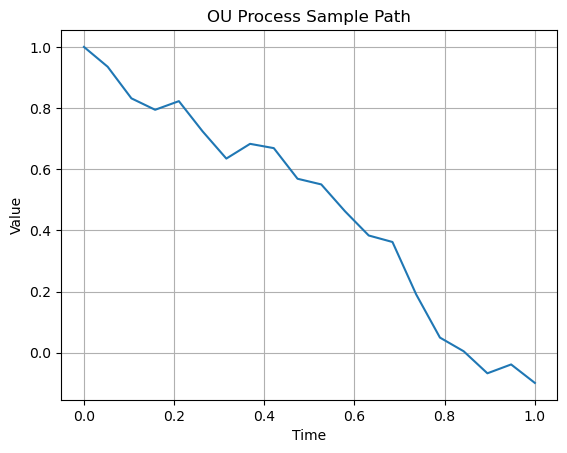

In [3]:
# Parameters
config = {
    'num_samples': 1000,
    'T': 10.0,
    'N': 20,
    'theta': 0.2,
    'mu': 0.0,
    'sigma': 0.1,
    'X0': 1.0,
    'train_ratio': 0.8,
    'batch_size': 16,
    'seed': 42,
}

# Ensure reproducibility
seed_everything(config['seed'])

# Generate data
total_data, coeffs, times = generate_data(config['num_samples'], config['T'], config['N'], config['theta'], config['mu'], config['sigma'], config['X0'])

# Split data
train_data, train_coeffs, test_data, test_coeffs = split_data(total_data, coeffs, config['train_ratio'])

# Create data loaders
train_loader, test_loader = create_data_loaders(train_data, train_coeffs, test_data, test_coeffs, config['batch_size'])

# Plot the first sample for verification
plt.plot(times.numpy(), total_data[0, :, 1].numpy())
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('OU Process Sample Path')
plt.grid('on')
plt.show()

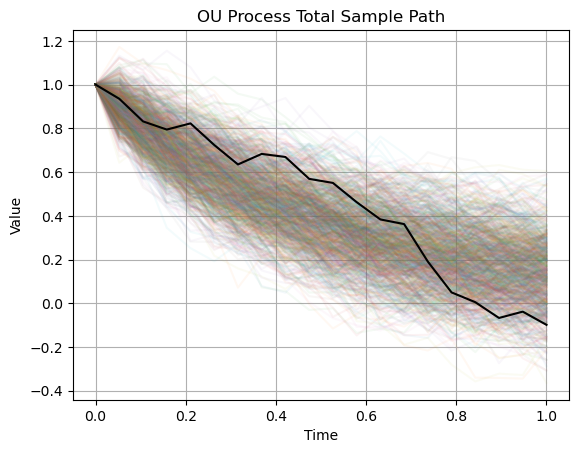

In [4]:
# Plot the whole samples for verification
for data in total_data:
    plt.plot(times.numpy(), data[:,1].numpy(), alpha=0.05)
plt.plot(times.numpy(), total_data[0, :, 1].numpy(), color='k')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('OU Process Total Sample Path')
plt.grid('on')
plt.show()

### Step 2: Define model

We can define Neural ODE as follows:

$$
dz(t) = f(t, z(t); \theta_f) dt
$$

Please refer original paper for the details: [https://arxiv.org/abs/1806.07366](https://arxiv.org/abs/1806.07366)

In [5]:
class LipSwish(nn.Module):
    def forward(self, x):
        return 0.909 * torch.nn.functional.silu(x)

class MLP(nn.Module):
    def __init__(self, in_size, out_size, hidden_dim, num_layers, tanh=False, activation='lipswish'):
        super().__init__()

        if activation == 'lipswish':
            activation_fn = LipSwish()
        else:
            activation_fn = nn.ReLU()

        model = [nn.Linear(in_size, hidden_dim), activation_fn]
        for _ in range(num_layers - 1):
            model.append(nn.Linear(hidden_dim, hidden_dim))
            model.append(activation_fn)
        model.append(nn.Linear(hidden_dim, out_size))
        if tanh:
            model.append(nn.Tanh())
        self._model = nn.Sequential(*model)

    def forward(self, x):
        return self._model(x)

class NeuralODEFunc(nn.Module):
    def __init__(self, input_dim, hidden_dim, hidden_hidden_dim, num_layers, activation='lipswish'):
        super(NeuralODEFunc, self).__init__()
        self.sde_type = "ito"
        self.noise_type = "scalar"

        self.linear_in = nn.Linear(hidden_dim + 1, hidden_dim)
        self.f_net = MLP(hidden_dim, hidden_dim, hidden_hidden_dim, num_layers, activation=activation)

    def set_X(self, coeffs, times):
        self.coeffs = coeffs
        self.times = times
        self.X = torchcde.CubicSpline(self.coeffs, self.times)
    
    def f(self, t, y):
        if t.dim() == 0:
            t = torch.full_like(y[:, 0], fill_value=t).unsqueeze(-1)
        # yy = self.linear_in(torch.cat((torch.sin(t), torch.cos(t), y), dim=-1))
        yy = self.linear_in(torch.cat((t, y), dim=-1))
        return self.f_net(yy)

    def g(self, t, y):
        return torch.zeros(y.size(0), y.size(1), 1).to(y.device)

class NDE_model(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, activation='lipswish', vector_field=None):
        super(NDE_model, self).__init__()
        self.func = vector_field(input_dim, hidden_dim, hidden_dim, num_layers, activation=activation)
        self.initial = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, output_dim)

    def forward(self, coeffs, times):
        # control module
        self.func.set_X(coeffs, times)

        y0 = self.func.X.evaluate(times[0])
        y0 = self.initial(y0)

        z = torchsde.sdeint(sde=self.func,
                            y0=y0,
                            ts=times,
                            dt=0.05,
                            method='euler')
        z = z.permute(1,0,2)
        return self.decoder(z)

In [6]:
input_dim = 2
output_dim = 1
hidden_dim = 32
num_layers = 1

model = NDE_model(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers, vector_field=NeuralODEFunc).to(device)

In [7]:
num_epochs = 100
lr = 1e-3

optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.MSELoss()

Test Loss: 0.29174524316420924


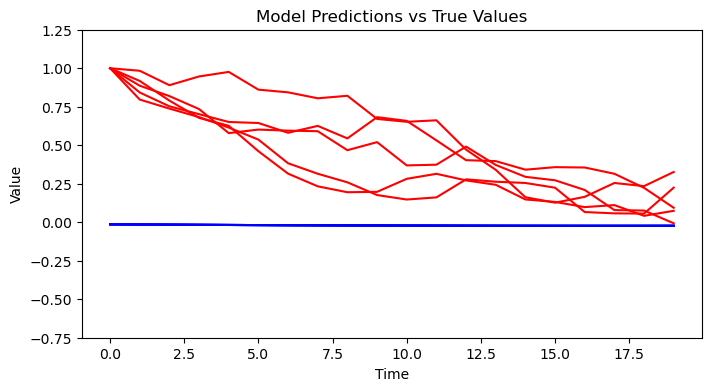

In [8]:
model.eval()
total_loss = 0
all_preds = []
all_trues = []
with torch.no_grad():
    for batch in test_loader:
        coeffs = batch[1].to(device)
        times = torch.linspace(0, 1, batch[0].shape[1]).to(device)

        true = batch[0][:,:,1].to(device)
        pred = model(coeffs, times).squeeze(-1)
        loss = criterion(pred, true)
        total_loss += loss.item()

        all_preds.append(pred.cpu())
        all_trues.append(true.cpu())

avg_loss = total_loss / len(test_loader)
print(f'Test Loss: {avg_loss}')

all_preds = torch.cat(all_preds, dim=0)
all_trues = torch.cat(all_trues, dim=0)

##
num_samples = 5

plt.figure(figsize=(8, 4))
for i in range(num_samples):
    plt.plot(all_trues[i].numpy(), color='r')
    plt.plot(all_preds[i].numpy(), color='b')
plt.xlabel('Time')
plt.ylabel('Value')
plt.ylim(-0.75,1.25)
plt.title('Model Predictions vs True Values')
plt.show()

Epoch 10, Loss: 0.019015553891658783
Test Loss: 0.01873352349950717


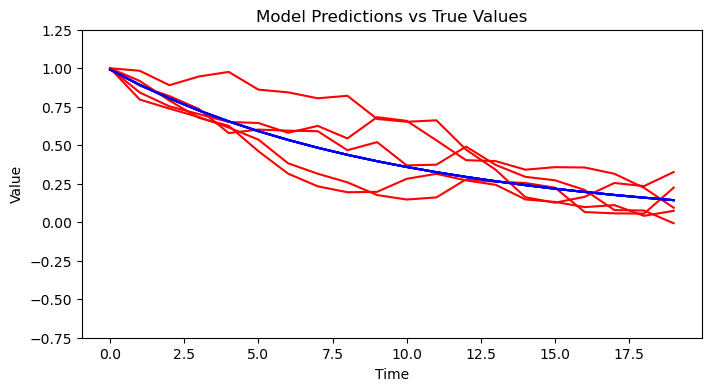

Epoch 20, Loss: 0.019250064734369517
Test Loss: 0.019222524375296555


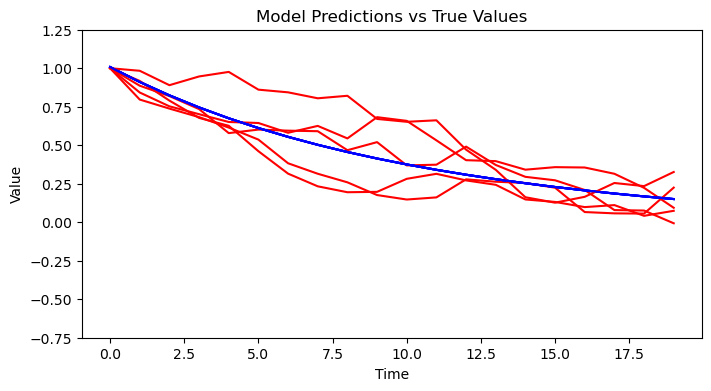

Epoch 30, Loss: 0.018927977625280618
Test Loss: 0.018896162080077026


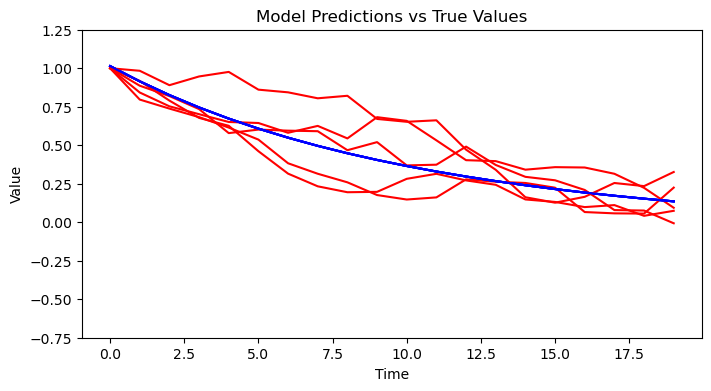

Epoch 40, Loss: 0.018747248109430074
Test Loss: 0.018687452619465496


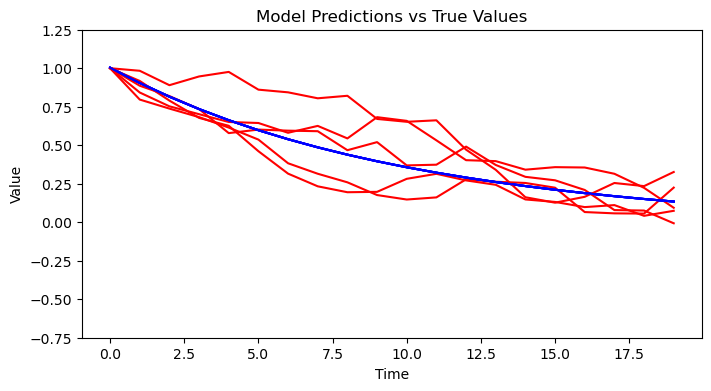

Epoch 50, Loss: 0.01892199842259288
Test Loss: 0.018635999482984725


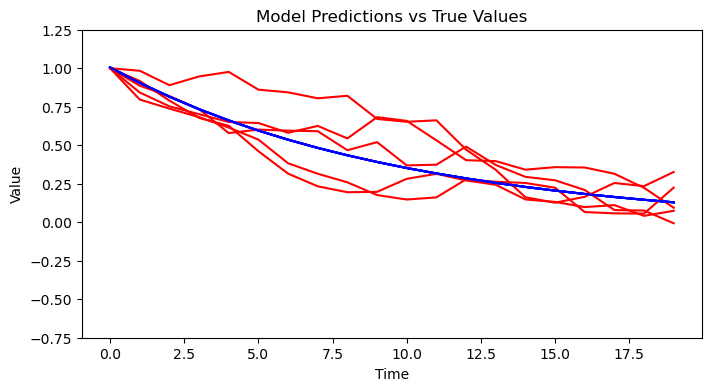

Epoch 60, Loss: 0.01899414462968707
Test Loss: 0.01861246360036043


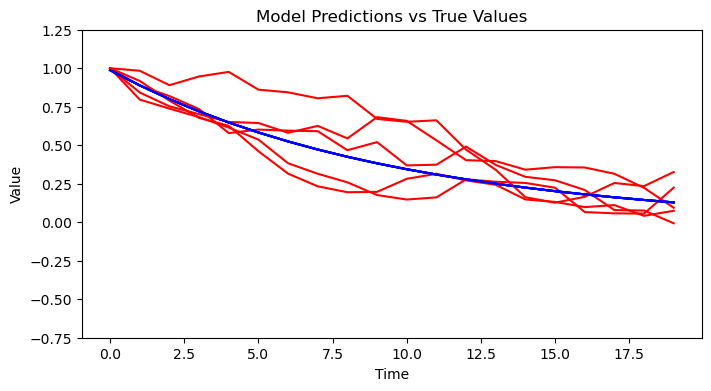

Epoch 70, Loss: 0.01904343079775572
Test Loss: 0.01861209737566801


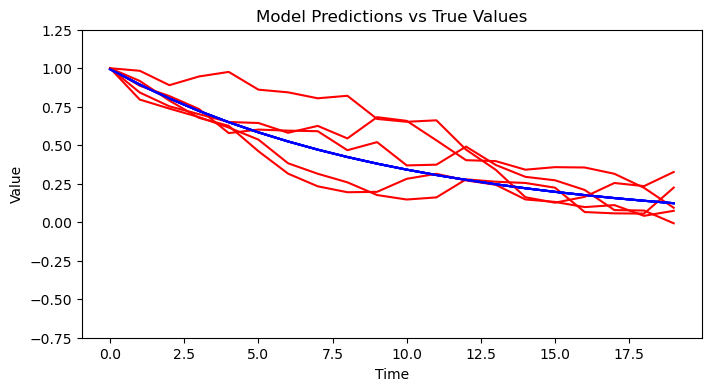

Epoch 80, Loss: 0.018767185769975187
Test Loss: 0.01892078223709877


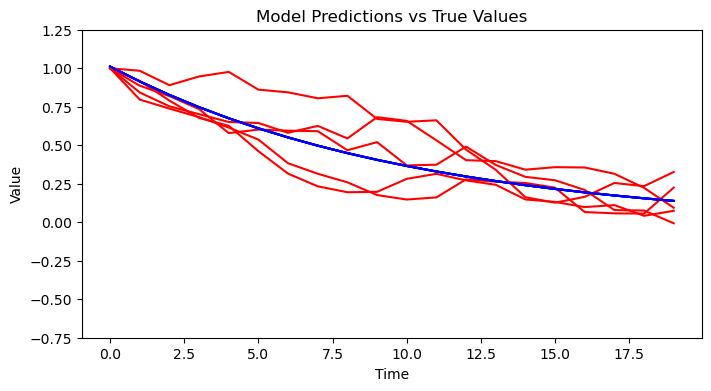

Epoch 90, Loss: 0.018804233279079197
Test Loss: 0.019026682927058294


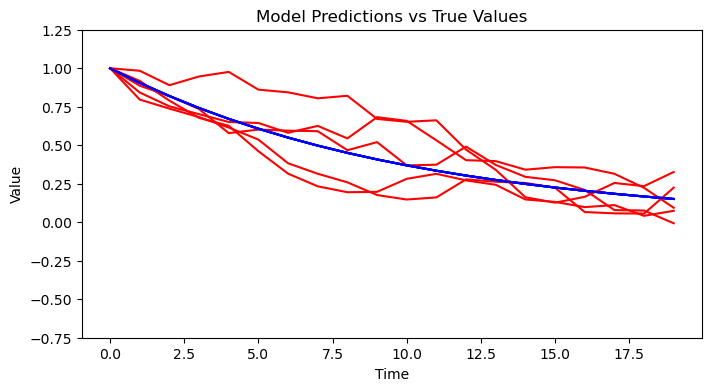

Epoch 100, Loss: 0.01877741899341345
Test Loss: 0.01861666837850442


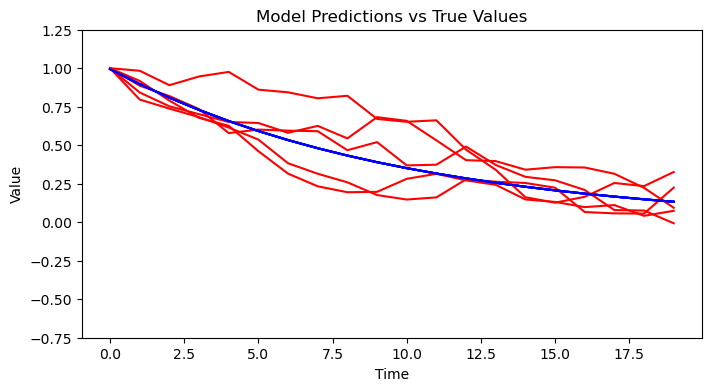

In [9]:
for epoch in range(1,num_epochs+1):
    model.train()
    total_loss = 0
    for batch in train_loader:
        coeffs = batch[1].to(device)
        times = torch.linspace(0, 1, batch[0].shape[1]).to(device)

        optimizer.zero_grad()
        true = batch[0][:,:,1].to(device)
        pred = model(coeffs, times).squeeze(-1)
        loss = criterion(pred, true)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 10 == 0:
        avg_loss = total_loss / len(train_loader)
        print(f'Epoch {epoch}, Loss: {avg_loss}')

        ##
        model.eval()
        total_loss = 0
        all_preds = []
        all_trues = []
        with torch.no_grad():
            for batch in test_loader:
                coeffs = batch[1].to(device)
                times = torch.linspace(0, 1, batch[0].shape[1]).to(device)
        
                true = batch[0][:,:,1].to(device)
                pred = model(coeffs, times).squeeze(-1)
                loss = criterion(pred, true)
                total_loss += loss.item()
        
                all_preds.append(pred.cpu())
                all_trues.append(true.cpu())
        
        avg_loss = total_loss / len(test_loader)
        print(f'Test Loss: {avg_loss}')
        
        all_preds = torch.cat(all_preds, dim=0)
        all_trues = torch.cat(all_trues, dim=0)
    
        ##      
        plt.figure(figsize=(8, 4))
        for i in range(num_samples):
            plt.plot(all_trues[i].numpy(), color='r')
            plt.plot(all_preds[i].numpy(), color='b')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.ylim(-0.75,1.25)
        plt.title('Model Predictions vs True Values')
        plt.show()

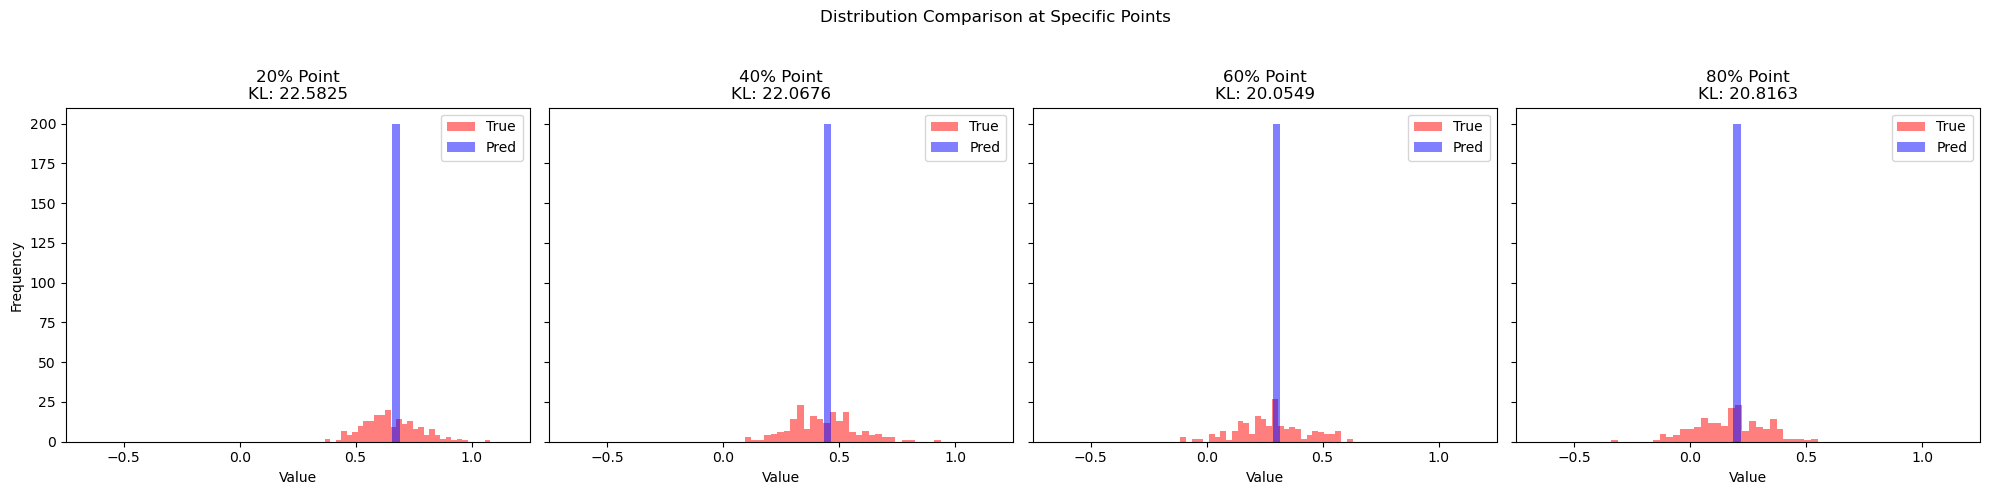

In [10]:
from scipy.stats import entropy

def calculate_kl_divergence(true_values, pred_values, num_bins=30):
    # Compute histogram for true and predicted values
    hist_true, bin_edges = np.histogram(true_values, bins=num_bins, density=True)
    hist_pred, _ = np.histogram(pred_values, bins=bin_edges, density=True)

    # Avoid division by zero and log(0) issues
    hist_true = np.where(hist_true == 0, 1e-10, hist_true)
    hist_pred = np.where(hist_pred == 0, 1e-10, hist_pred)

    # Calculate KL divergence
    kl_div = entropy(hist_true, hist_pred)
    return kl_div

def compare_distributions(true_data, pred_data, points, num_bins=30):
    time_points = [int(p * true_data.shape[1]) for p in points]
    
    fig, axes = plt.subplots(1, len(points), figsize=(20, 5), sharey=True)
    
    for ax, point, time_point in zip(axes, points, time_points):
        true_values = true_data[:, time_point].numpy()
        pred_values = pred_data[:, time_point].numpy()
        
        kl_div = calculate_kl_divergence(true_values, pred_values, num_bins)

        ax.hist([round(v,5) for v in true_values], bins=num_bins, alpha=0.5, label='True', color='r')
        ax.hist([round(v,5) for v in pred_values], bins=num_bins, alpha=0.5, label='Pred', color='b')
        ax.set_title(f'{int(point * 100)}% Point\nKL: {kl_div:.4f}')
        ax.set_xlabel('Value')
        ax.set_xlim(-0.75,1.25)
        ax.set_xticks([-0.5,0.0,0.5,1.0])
        if ax == axes[0]:
            ax.set_ylabel('Frequency')
        ax.legend()

    plt.suptitle('Distribution Comparison at Specific Points')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

points_to_compare = [0.2, 0.4, 0.6, 0.8]
compare_distributions(all_trues, all_preds, points_to_compare)

## Theory Check

This notebook is a deterministic continuous-flow baseline. The code cell below verifies that the diffusion term is identically zero and that repeated solves remain deterministic under seed changes.


{'max_abs_diffusion': 0.0, 'repeat_solve_max_diff': 0.0}


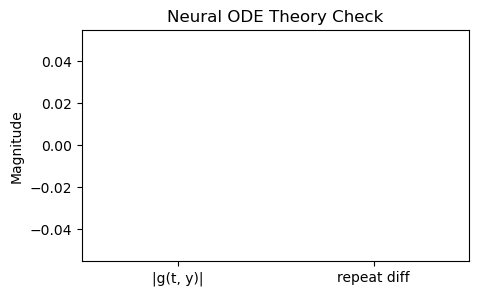

In [11]:
model.eval()
theory_batch = next(iter(test_loader))
theory_coeffs = theory_batch[1].to(device)
theory_times = torch.linspace(0, 1, theory_batch[0].shape[1]).to(device)
model.func.set_X(theory_coeffs, theory_times)
theory_y0 = model.initial(model.func.X.evaluate(theory_times[0]))
zero_diffusion = model.func.g(theory_times[0], theory_y0)
seed_everything(config['seed'])
pred_a = model(theory_coeffs, theory_times).detach().cpu()
seed_everything(config['seed'] + 1)
pred_b = model(theory_coeffs, theory_times).detach().cpu()
repeat_diff = float((pred_a - pred_b).abs().max().item())
print({'max_abs_diffusion': float(zero_diffusion.abs().max().item()), 'repeat_solve_max_diff': repeat_diff})
plt.figure(figsize=(5, 3))
plt.bar(['|g(t, y)|', 'repeat diff'], [float(zero_diffusion.abs().max().item()), repeat_diff], color=['tab:green', 'tab:blue'])
plt.title('Neural ODE Theory Check')
plt.ylabel('Magnitude')
plt.show()
